# Notebook 1: Data quality ans cleanning

The purpose of this exerecise is to demostrate my data analysis skills using Python. It also a way for me to get more in depth understanding of the position of Quantitative Risk Analyst at Nordea.

The goal of this exercise is to demonstrate the probability of default of loan applicants. It has been diveded into three parts: 
1. Data quality and cleaning
2. Feature engineering and risk analysis
3. Credit Risk model

Origin of data: https://www.kaggle.com/datasets/burak3ergun/loan-data-set/code

As a resource for understanding credit loan data and how it is normally processed I used the following resources made by Muhammad Faizin Zen in Medium:
- Building a Credit Score Model: Understanding the Business Context and Dataset (https://medium.com/@zaynmuhammad20/building-a-credit-score-model-understanding-the-business-context-and-dataset-426245d83e63)
- Building a Credit Score Model: Handling Missing Values and Outliers (https://medium.com/@zaynmuhammad20/building-a-credit-score-model-handling-missing-values-and-outliers-ceb501b3b7b7)
- Building a Credit Score Model: Feature Engineering and Encoding (https://medium.com/@zaynmuhammad20/building-a-credit-score-model-feature-engineering-and-encoding-999373e0b9bb)
- Building a Credit Score Model: Feature Selection (https://medium.com/@zaynmuhammad20/building-a-credit-score-model-feature-selection-516e5c54ed53)
- Building a Credit Score Model: Model Selection, Training, and Evaluation (https://medium.com/@zaynmuhammad20/building-a-credit-score-model-model-selection-training-and-evaluation-b7c2fc179feb)
- Building a Credit Score Model: Hyperparameter Tuning for an Optimized Credit Scoring Model (https://medium.com/@zaynmuhammad20/building-a-credit-score-model-hyperparameter-tuning-for-an-optimized-credit-scoring-model-d2f803db5dec)

<h1 style="text-align: center;">Variables in Data explained</h1>

| Column | Description |
|------|-------------|
| **Loan_ID** | Unique identifier for each loan application |
| **Gender** | Gender of the applicant |
| **Married** | Marital status of the applicant |
| **Dependents** | Number of dependents the applicant has |
| **Education** | Education level of the applicant (Graduate or Not Graduate) |
| **Self_Employed** | Whether the applicant is self-employed |
| **ApplicantIncome** | Income of the applicant |
| **CoapplicantIncome** | Income of the co-applicant (if any) |
| **LoanAmount** | Amount of the loan applied for |
| **Loan_Amount_Term** | Term of the loan in months |
| **Credit_History** | Credit history of the applicant (1 = good credit history, 0 = poor credit history) |
| **Property_Area** | Area where the property is located (Urban, Rural, Semiurban) |
| **Loan_Status** | Whether the loan was approved (Y = approved, N = not approved) |

# Table of contents
## 1. Downloading, inspecting, and uniforming Data
## 2. Data visualization
### 2.1 Visualisation of missing values
## 3. Missing value identification
### 3.1 Identification of Missing values
### 
### 3.2 Transforming Data
### 

In [1]:
import pandas as pd
import numpy as np
import scipy as sc
from scipy.stats import pointbiserialr, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# 1. Downloading, inspecting, and uniforming Data

In [2]:
df = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\loan_data_set.csv")
pd.set_option("display.max_colwidth", None)
#New DataFrame for making final changes in df. loan_df is used to look at original data
df = df.rename(columns={"ApplicantIncome": "Applicant_Income", "CoapplicantIncome": "Coapplicant_Income", "LoanAmount": "Loan_Amount"})
print("Size of dataframe:",df.shape)
df.head()

Size of dataframe: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
#Looking at datatypes and missing values
print(df.info()," \n")
#Precentage of missing values
print("Precentage of missing data", ((df.isna().sum().sum())/len(df))*100, "% \n")
#also check duplication of rows
print("Duplicated rows:", len(df)-len(df.drop_duplicates()))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             614 non-null    object 
 1   Gender              601 non-null    object 
 2   Married             611 non-null    object 
 3   Dependents          599 non-null    object 
 4   Education           614 non-null    object 
 5   Self_Employed       582 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         592 non-null    float64
 9   Loan_Amount_Term    600 non-null    float64
 10  Credit_History      564 non-null    float64
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None  

Precentage of missing data 24.267100977198698 % 

Duplicated rows: 0


In [4]:
df.describe()

,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


From this we can see majority of the data is in the wrong kind of form and needs to be transformed the following:
 1. Loan_ID in a running number so it should be string
 2. Gender, Dependents, Education,Self_Employed, Loan_Amount_Term, Credit_History, Property_Area, and Loan_Status are all categorical values and can be changed to binary (0/1) values to ease analysis.
 3. Applicant_Income, Coapplicant_Income, and Loan_Amount are all  so called continues measurements and so should be numeric
<br>
<br>Before all data can be transformed into corrrect types, missing values need to esimated. The will be made uniform the following way : Loan_ID will be made string; Gender, Dependents, Education,Self_Employed, Loan_Amount_Term, Credit_History, Property_Area, and Loan_Status object; and Applicant_Income, Coapplicant_Income, and Loan_Amount float

In [5]:
#Making datatypes uniform across different types of values
df["Loan_ID"] = df["Loan_ID"].astype("string")
df["Applicant_Income"] = df["Applicant_Income"].astype("float64")
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].astype("object")
df["Credit_History"] = df["Credit_History"].astype("object")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             614 non-null    string 
 1   Gender              601 non-null    object 
 2   Married             611 non-null    object 
 3   Dependents          599 non-null    object 
 4   Education           614 non-null    object 
 5   Self_Employed       582 non-null    object 
 6   Applicant_Income    614 non-null    float64
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         592 non-null    float64
 9   Loan_Amount_Term    600 non-null    object 
 10  Credit_History      564 non-null    object 
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(3), object(9), string(1)
memory usage: 62.5+ KB


## 2. Data visualisation

**At this point only missing data will be looked since plotting data with mssing values could give wrong conclusions**

### 2.1 Visualization of missing values

Percentage of missing data 22.149837133550488 %

Percentage of missing values per columns:
 Loan_ID               0.000000
Gender                2.117264
Married               0.488599
Dependents            2.442997
Education             0.000000
Self_Employed         5.211726
Applicant_Income      0.000000
Coapplicant_Income    0.000000
Loan_Amount           3.583062
Loan_Amount_Term      2.280130
Credit_History        8.143322
Property_Area         0.000000
Loan_Status           0.000000
dtype: float64


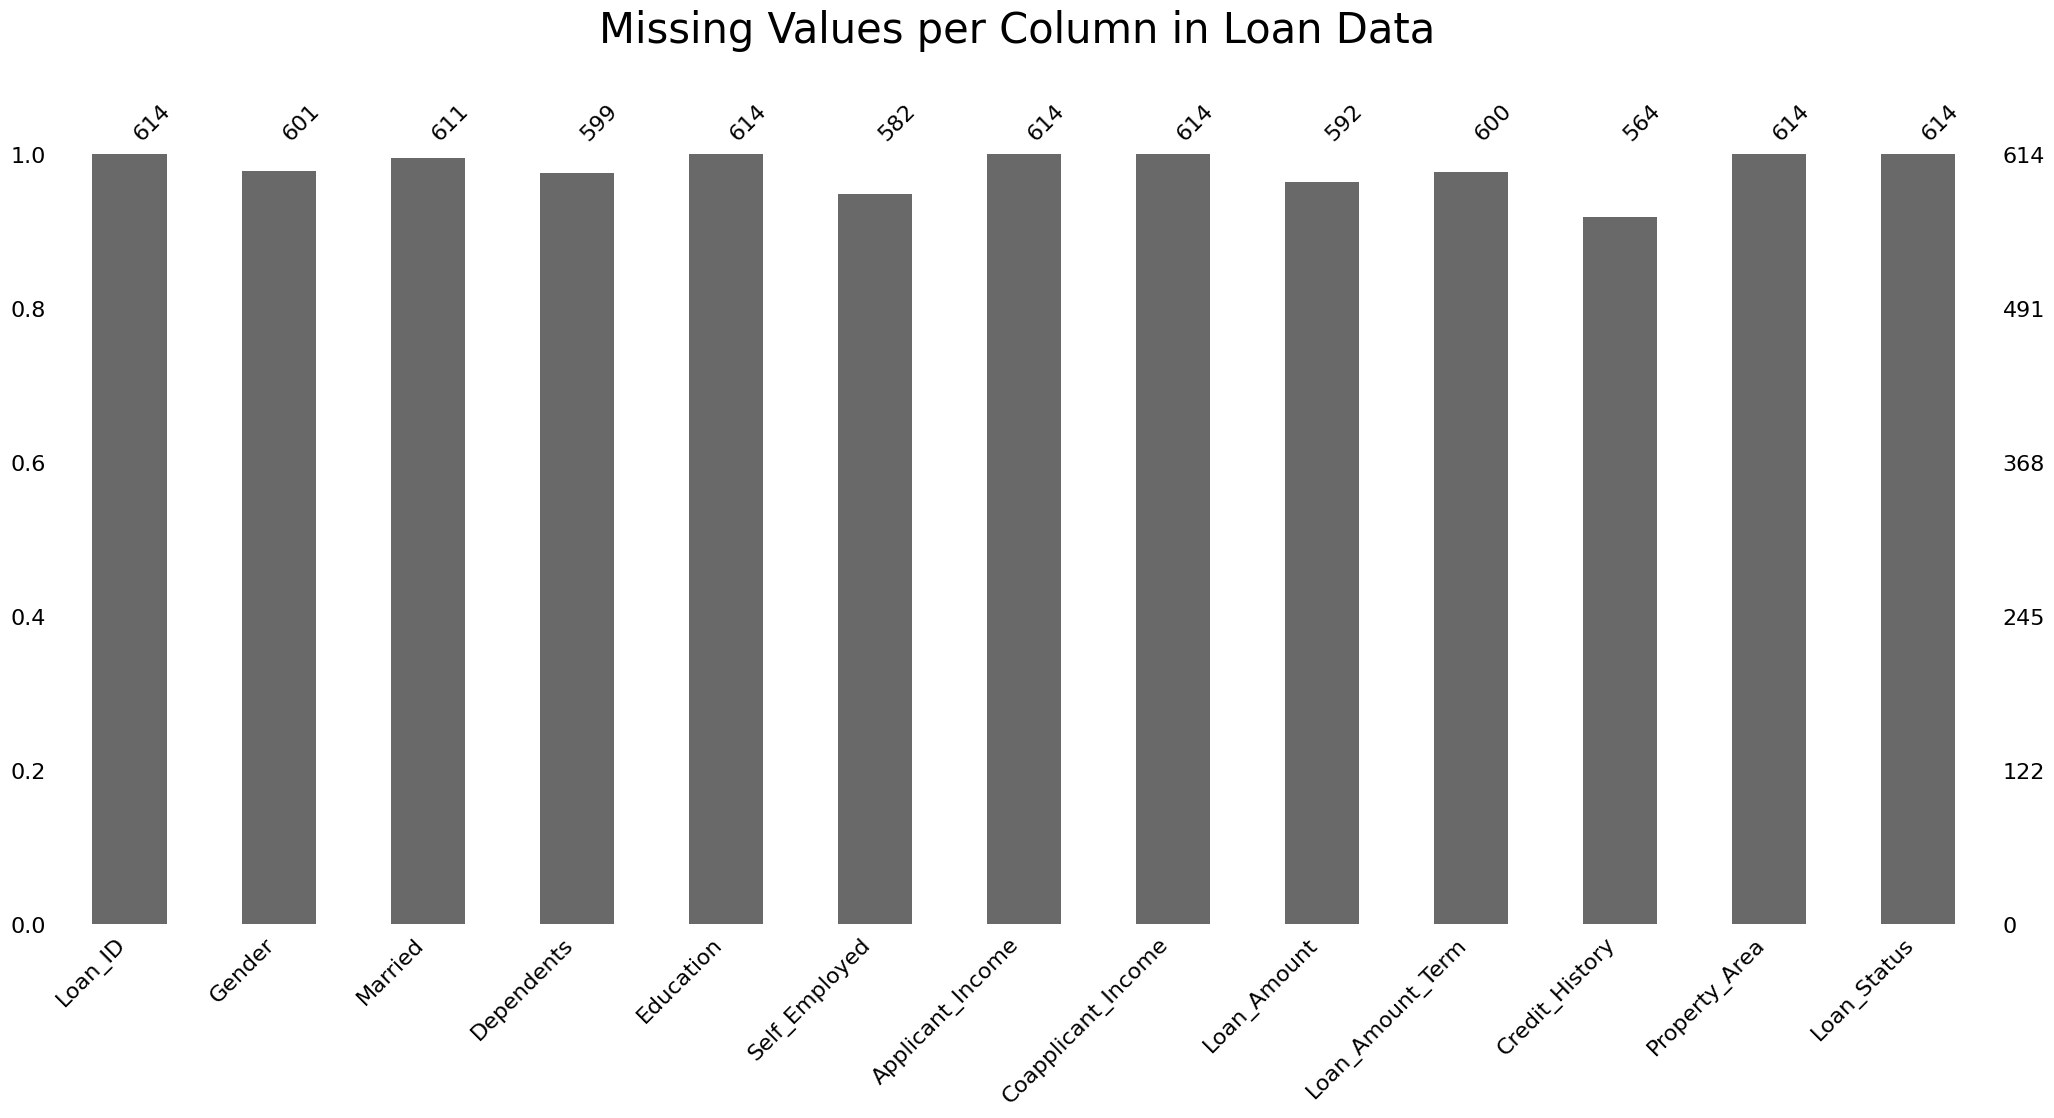

In [6]:
#Calculation of data that could be removed
print("Percentage of missing data", ((df.isna().sum().sum()-13)/len(df))*100, "%\n")
print("Percentage of missing values per columns:\n",(df.isna().sum()/len(df))*100)

#Visualizing amount of data missing
msno.bar(df)
plt.title("Missing Values per Column in Loan Data \n",fontsize=30) 
plt.show()

<Figure size 1000x400 with 0 Axes>

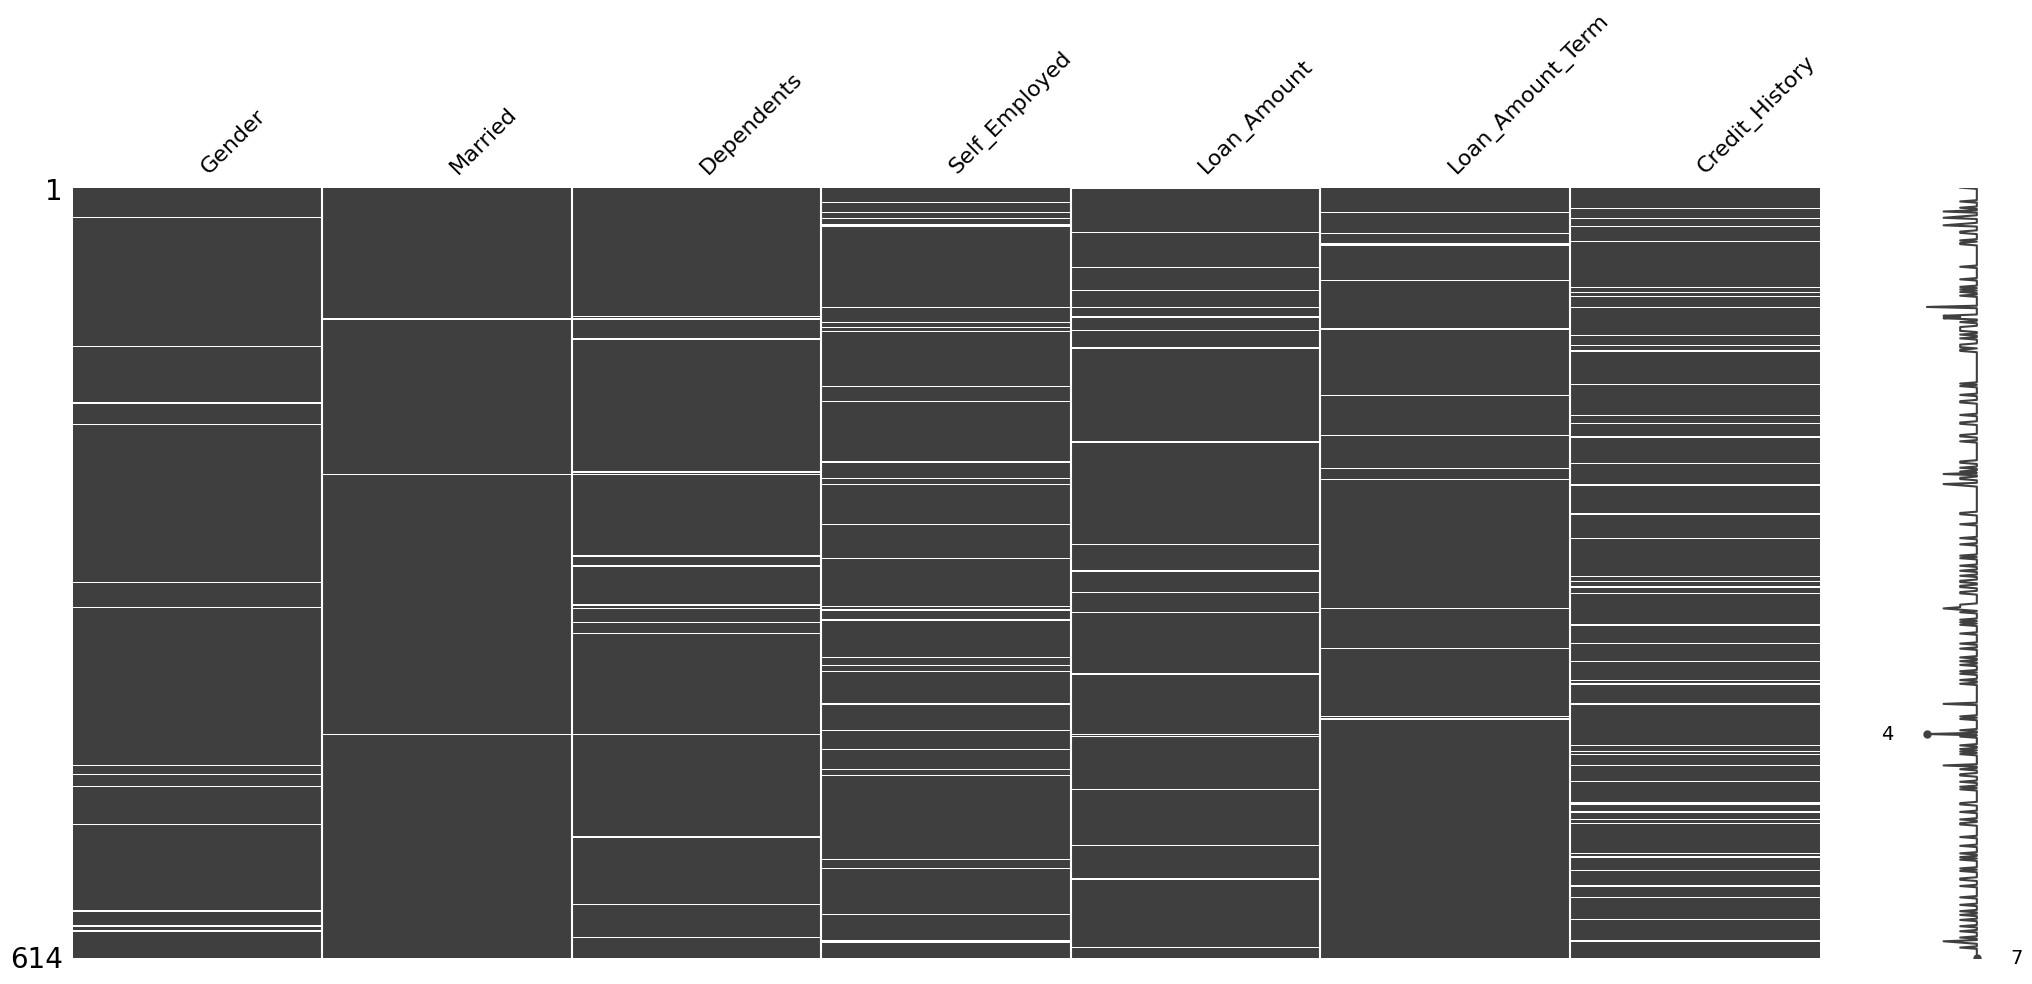

In [7]:
#Shows where missing data is in the df.
columns_missing = df.columns[df.isna().any()]
plt.figure(figsize=(10,4))
msno.matrix(df[columns_missing])
plt.show()

There are few visual correlation, like missing data for people how have not told about maritial status and telling about dependants.  

# 3. Missing value identification

## 3.1 Identification of missing values

~22% of all data is missing from the dataframe. This is significant amount of data ehich means rows can not be deleted. The options are to fill missing values with 0, median (numeric values)/mode (categorical) or to make a predictative machine learning model. The most logical option in this case is to fill the values with either median/mode. This is because making a predictive model would most likely give us an overfitted value because the dataset is small. <br>

Even though the previous is true, I want to figure out are the values MCAR or MAR. I'm making the assumption that none of the values are MNAR because it is difficult to detect without deep knowledge and understanding of the data and the amount of missing values are a max of ~8%. ALso the amount of data overall is significant (22%) so usming randomness is justified.<br>

I have created a basic function to estimate if the missing values are MCAR or MAR. Based on this I will fill the missing values with either median (numeric values) or mode (categorical/binary). I'm going to do this because the amount of missing data/per column is not so much  and the dataset is small, so predict values with a ML-model could over it and give skewed data.

#### What this function does
<br> <i>**The function calculates how the removal of missing values affects the data as a whole. If removing the data point doesn't significantly (p < 0.05) affect the data, the data is assumed to be MCAR. If a correlation between values is identified it is assumed the values are MAR. In theory MCAR values could be removed without affectinf data. MAR values should not be removed because removing them could affect future analysis and should be replaced with median/mode or a predicticted value.
<br>The function tests whether the missingness of a variable is associated with other variables in the dataset. A binary missingness indicator (1 = missing, 0 = observed) is created for each variable with missing values. Relationships with numeric variables are tested using point-biserial correlation, while relationships with categorical variables are tested using the chi-square test of independence.**

Because multiple statistical tests are performed, a Bonferroni correction is applied to control the family-wise error rate. This adjusts the significance threshold to reduce the probability of false positives when testing many variables simultaneously.

If no statistically significant relationships are found after the correction, the missing values are assumed to be Missing Completely At Random (MCAR). If a significant relationship exists, the missing values are considered Missing At Random (MAR), meaning the probability of missingness depends on other observed variables. In practice, MCAR values may be removed without introducing bias, whereas MAR values should typically be imputed, for example using the median for numeric variables and the mode for categorical variables.

In [8]:
def estimation_missing_values(df, alpha=0.05):
    rows = []
    n_rows = len(df)
    
    #Defining which columns are numeric values, and categorical values, and columns with missing values
    missing_cols = df.columns[df.isna().any()]
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

    #Going through missing columns and turning values in columns binary
    for col in missing_cols:
        y = df[col].isna().astype(int)
        prediction = []
        
        # Calculation of missing values per colunm
        missing_count = df[col].isna().sum()
        missing_pct = (missing_count / n_rows)*100
        
        # Number of statistical tests for Bonferroni correction
        n_tests = (len(df.columns) - 1)
        alpha_corr = alpha / n_tests if n_tests > 0 else alpha

        # Going through numeric columns with missing values and filling missing values with median values
        for num in numeric_cols:
            if num == col:
                continue
            x = df[num]
            #Filtering data so I can actually see the meaning of removing the value
            filt = (~y.isna()) & (~x.isna())
            x_filt, y_filt = x[filt], y[filt]
            if len(np.unique(y_filt)) > 1 and len(np.unique(x_filt)) > 1:
                try:
                    #Calculating p-value for numeric data
                    r, p = pointbiserialr(y_filt, x_filt)
                    if p < alpha_corr:
                        prediction.append(f"{num} (num, p={p:.3f})")
                except Exception:
                    continue

        # Going through categorical columns with missing values and filling missing values with mode value
        for cat in categorical_cols:
            if cat == col:
                continue
            x = df[cat]
            filt = (~y.isna()) & (~x.isna())
            x_filt, y_filt = x[filt], y[filt]
            table = pd.crosstab(x_filt, y_filt)
            if table.shape[0] > 1 and table.shape[1] > 1:
                #Calculating chi squered for categorical data
                try:
                    _, p, _, _ = chi2_contingency(table)
                    if p < alpha_corr:
                        prediction.append(f"{cat} (cat, p={p:.3f})")
                except Exception:
                    continue

        # Determine missingness mechanism
        if prediction:
            mech = "Evidence against MCAR (possible MAR)"
        else:
            mech = "Consistent with MCAR"

        rows.append({
            "Column": col,
            "Missing Count": missing_count,
            "Missing %": round(missing_pct, 2),
            "Missingness Mechanism": mech,
            "Significant Predictors": ", ".join(prediction) if prediction else "-"
        })

    return pd.DataFrame(rows)

estimation_missing_values(df)

,Column,Missing Count,Missing %,Missingness Mechanism,Significant Predictors
0,Gender,13,2.12,Evidence against MCAR (possible MAR),"Applicant_Income (num, p=0.003)"
1,Married,3,0.49,Evidence against MCAR (possible MAR),"Loan_Amount_Term (cat, p=0.000)"
2,Dependents,15,2.44,Consistent with MCAR,-
3,Self_Employed,32,5.21,Consistent with MCAR,-
4,Loan_Amount,22,3.58,Consistent with MCAR,-
5,Loan_Amount_Term,14,2.28,Consistent with MCAR,-
6,Credit_History,50,8.14,Consistent with MCAR,-


Even though from analysing if missing values are MCAR or MAR, rows shouldn't be dropped. Since the amount of data missing is significant (over 20%), these values should be filled with median (numeric data) or mode (categorical data). Credit_History is missing most values (over 8%) in theory this should be filled with a predicted value (either person has good credit history (Y) or does not (N)) but for ease of this experiment this will not be done but results should be look at with this in mind

### 3.1.1 Adding values in place of missing data

In [9]:
# fill missing values
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

#At this step I want to easily demonstrate plots of graphs and skewness. If Loan_Amount_Term and Credit_Hisotry were
#numeic, it would calculate skewness for them as well and not give value counts which I want to see
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].astype("object")
df["Credit_History"] = df["Credit_History"].astype("object")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             614 non-null    string 
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    object 
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    float64
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    float64
 9   Loan_Amount_Term    614 non-null    object 
 10  Credit_History      614 non-null    object 
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(3), object(9), string(1)
memory usage: 62.5+ KB


### 3.2.2 Visualising data to identify skewness

I have identified Applicant_Income and Coapplicant_Income as skewed values. I want look at the rest of non-categorical data to see if it has the same issues.

In [11]:
#Selecting columns with datatype float64 or type int8
numeric_col = df.select_dtypes(include=["float64"]).columns
categorical_col = df.select_dtypes(include=["object"]).columns

### 2.1.1 Visualization of Categorical data

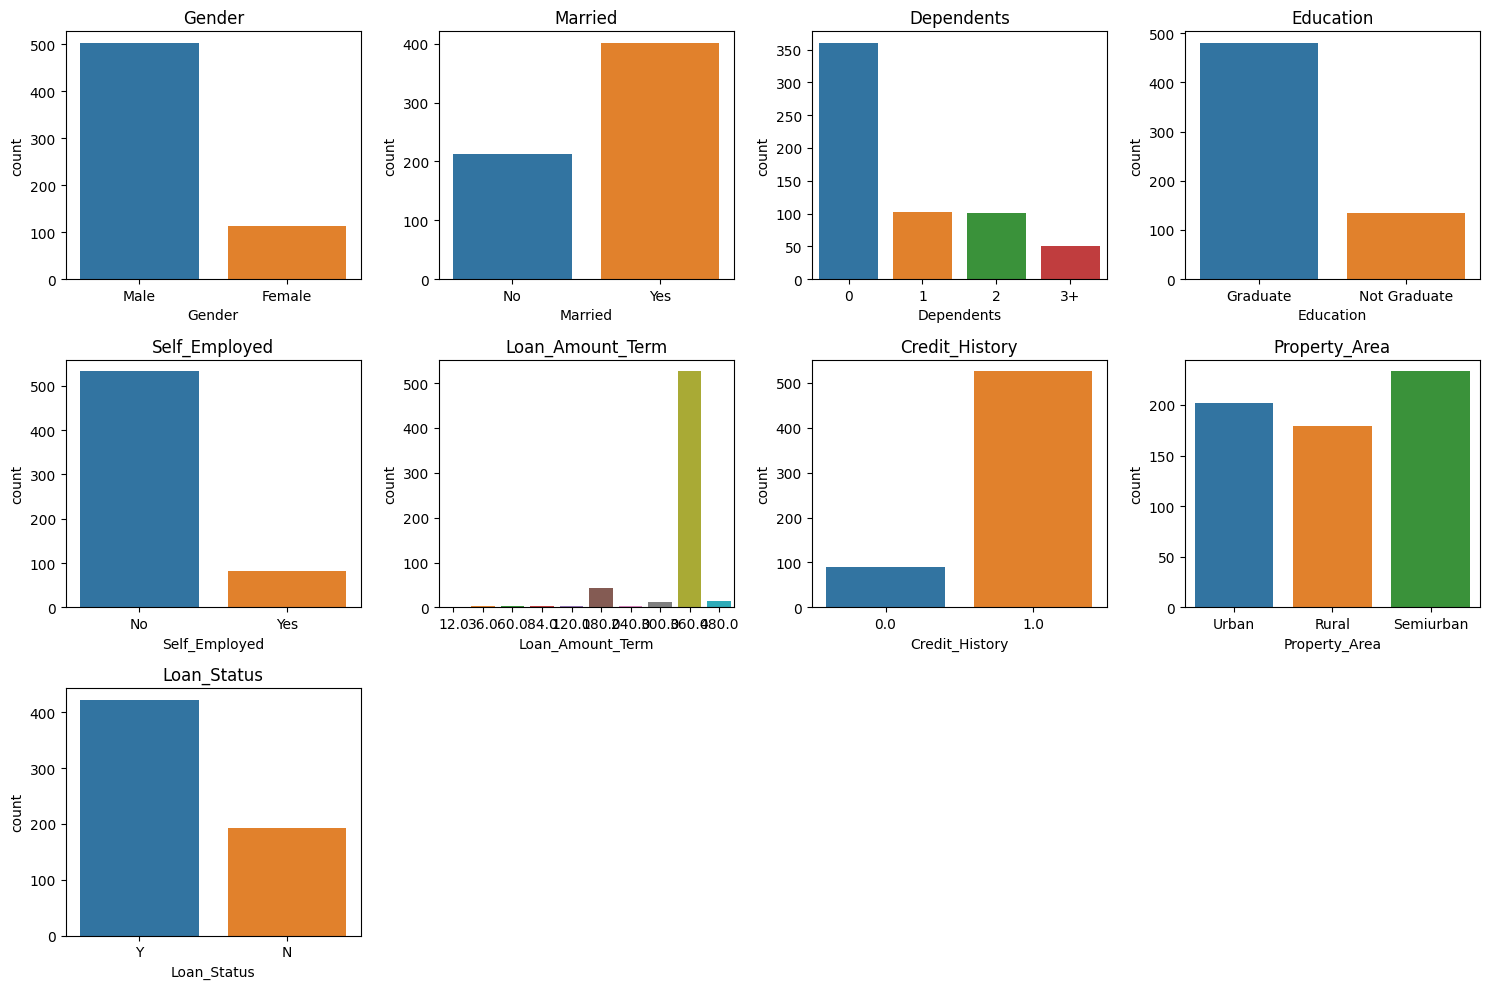

In [12]:
plt.figure(figsize=(15,10))

for i, col in enumerate(categorical_col):
    plt.subplot(3, 4, i+1) 
    sns.countplot(data=df, x=col)
    plt.title(col)

plt.tight_layout()
plt.show()

From this we can see majority of loans have been accepted. Also we can see Loan_Amount_Term column has a lot of variables.

### 2.1.2 Visualization of numeric data

       Applicant_Income  Coapplicant_Income  Loan_Amount
count        614.000000          614.000000   614.000000
mean        5403.459283         1621.245798   145.752443
std         6109.041673         2926.248369    84.107233
min          150.000000            0.000000     9.000000
25%         2877.500000            0.000000   100.250000
50%         3812.500000         1188.500000   128.000000
75%         5795.000000         2297.250000   164.750000
max        81000.000000        41667.000000   700.000000


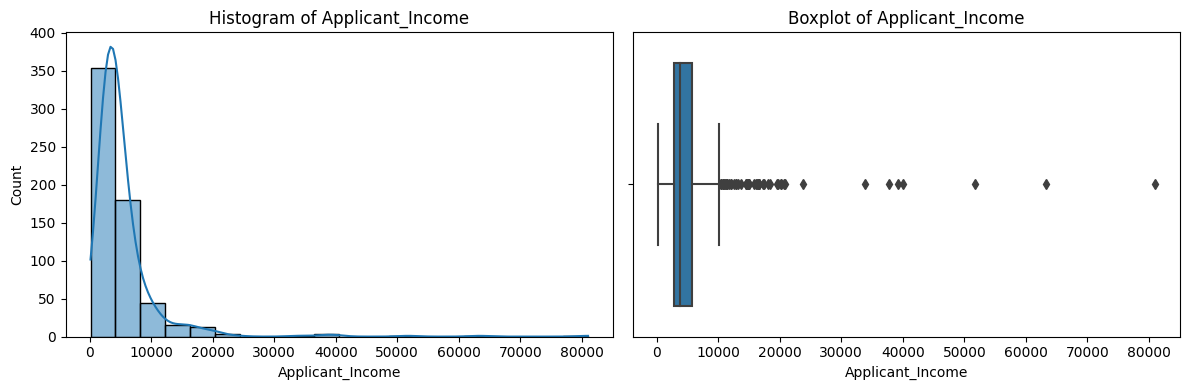

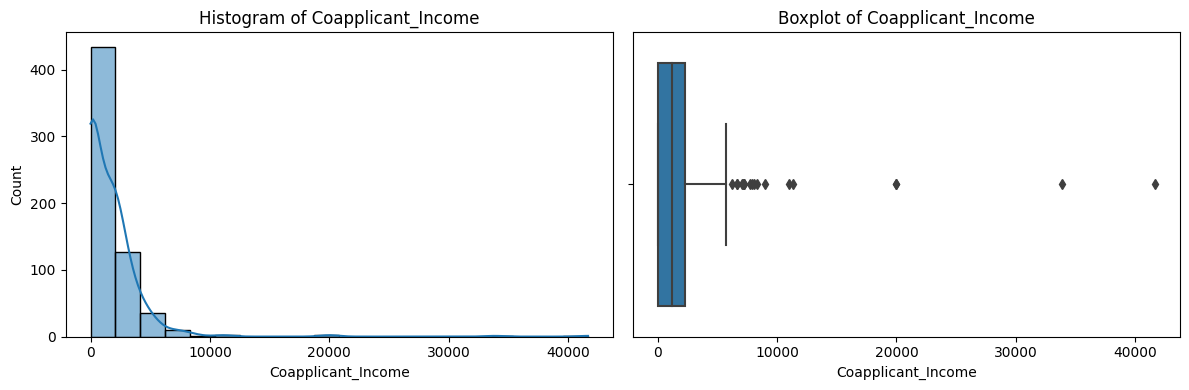

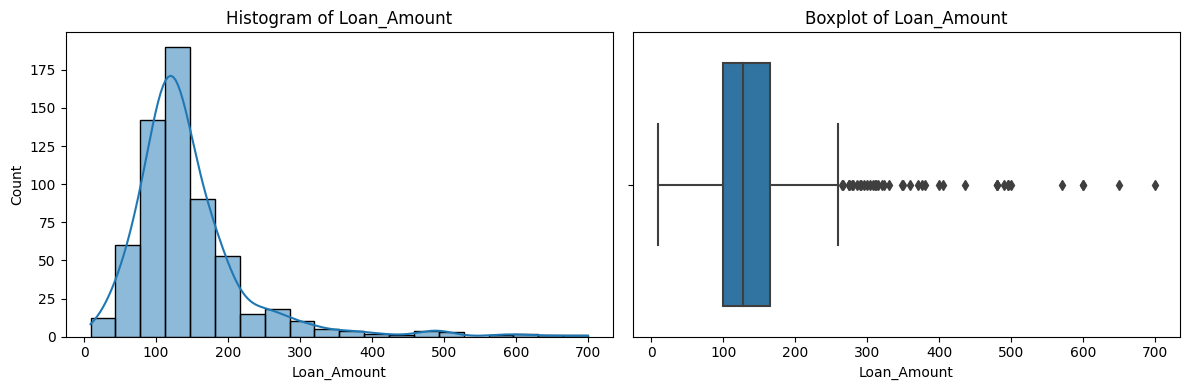

In [13]:
print(df.describe())

for i in numeric_col:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(df[i], bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {i}")

    # Boxplot
    sns.boxplot(x=df[i], ax=axes[1])
    axes[1].set_title(f"Boxplot of {i}")

    plt.tight_layout()
    plt.show()

In [14]:
#Calculating skewness of data determine
for i in numeric_col:
    skew = df[numeric_col].skew() 
print("Skewness of numeric data:\n", skew)

Skewness of numeric data:
 Applicant_Income      6.539513
Coapplicant_Income    7.491531
Loan_Amount           2.743053
dtype: float64


These graphs clearly show skewness in data. This means that the data is not evanly distributed. The long right tails in Histograms which are also shown in the boxplots are usual signs of this. This will be looked at more in detail in the next part of the analysis.

### Plotting columns together

We can see from the plots before, feature Coapplicant_Income is extremely skewed and hard intrepit. We have data of people who are married and also who have dependents. I want to plot these together to see if there is a correlation of maritial status and dependents, Coapplicant_Income and maritial status, and Coapplicant_Income and number of dependents

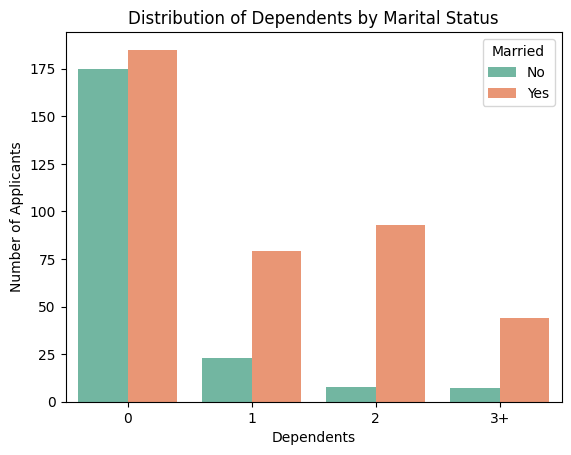

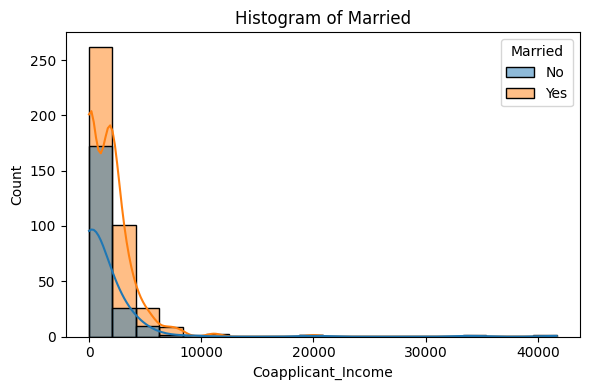

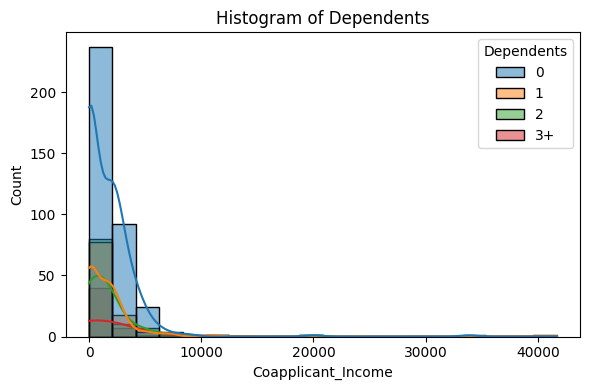

In [15]:
sns.countplot(data=df, x='Dependents',hue='Married',palette='Set2')
plt.title("Distribution of Dependents by Marital Status")
plt.xlabel("Dependents")
plt.ylabel("Number of Applicants")
plt.legend(title="Married")
plt.show()

for i in ["Married", "Dependents"]:
    fig, axes = plt.subplots(figsize=(6, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(df[i], x = df["Coapplicant_Income"], hue=df[i], bins=20, kde=True)
    axes.set_title(f"Histogram of {i}")
    plt.tight_layout()
    plt.show()


*We can see from the plots that there isn't really a correlation between number of dependents and maritial status. This can be seen because the amount of people who are married and who aren't both have equal amounts of datapoints in 0 dependents. Also, seeing correlation between maritial status and number dependants with Coapplucant_Income from these is extremely difficult because the data is still extremly positively skewed.
This is why I want to create a filter that removes people who have no dependents and no Coapplicant income. This could help visualizing if there is a difference in the data and if the people who have no dependents and coapplicant_income have a negative effect on analysis.*

From the plots, there does not appear to be a strong relationship between the number of dependents and marital status. This can be observed because both married and unmarried applicants have a similar number of observations in the 0 dependents category.

Additionally, identifying any relationship between marital status, number of dependents, and Coapplicant_Income is difficult because the income data is extremely positively skewed.

To better explore potential patterns in the data, a filter will be applied to remove applicants who have both zero dependents and zero coapplicant income. These observations may obscure relationships in the data because they represent applicants without additional household financial contributors.

By filtering these cases, it may become easier to visualize whether marital status and number of dependents have a clearer relationship with Coapplicant_Income, and to assess whether these observations negatively affect the analysis.

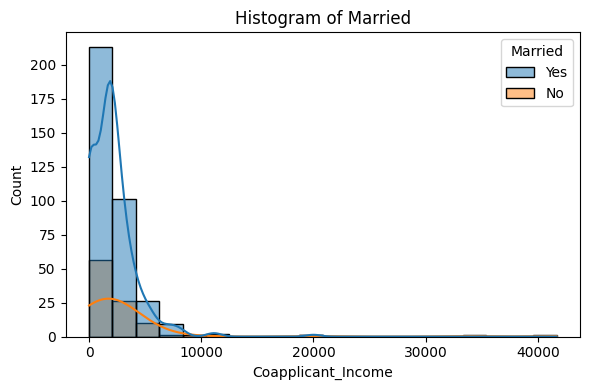

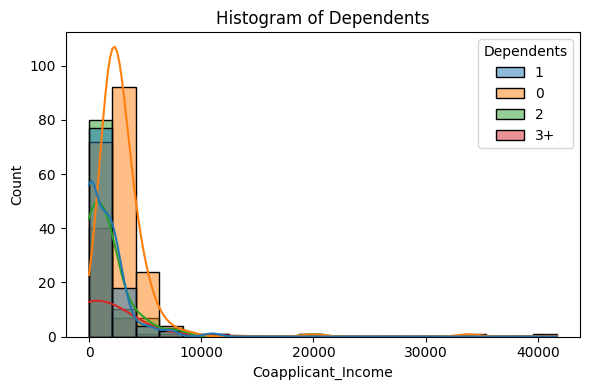

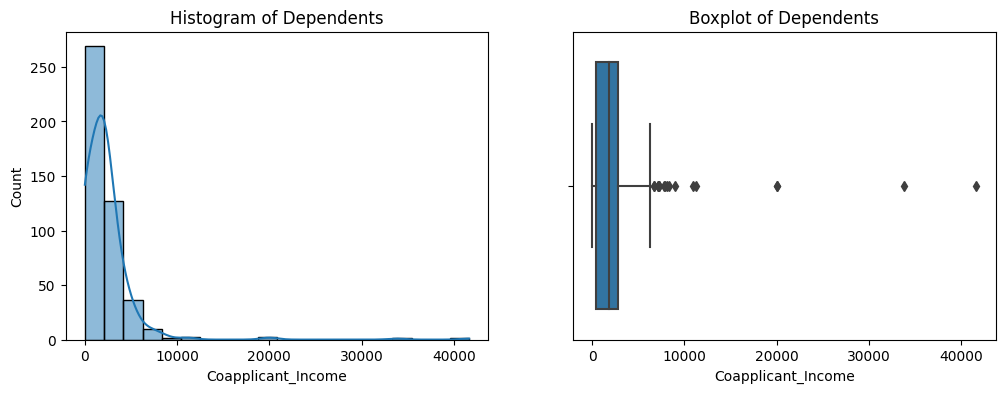

Skewness of numeric data: 7.159263800616969


In [16]:
#I want to see what the distrubutuon of data looks like if i filter out peole how have 0 dependents and 0 Coaaplicant_Income
df_test = df.copy()

df_filtered = df_test[~((df["Dependents"] == "0") & (df_test["Coapplicant_Income"] == 0))]

for i in ["Married","Dependents"]:
    fig, axes = plt.subplots(figsize=(6, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(df[i], x = df_filtered["Coapplicant_Income"], hue=df_filtered[i], bins=20, kde=True)
    axes.set_title(f"Histogram of {i}")
    plt.tight_layout()
    plt.show()
    
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram
sns.histplot(df_filtered["Coapplicant_Income"], bins=20, kde=True, ax=axes[0])
axes[0].set_title(f"Histogram of {i}")

# Boxplot
sns.boxplot(x=df_filtered["Coapplicant_Income"], ax=axes[1])
axes[1].set_title(f"Boxplot of {i}")

plt.show()

print("Skewness of numeric data:", df_filtered["Coapplicant_Income"].skew() )

As we can see, removing the data made it significantly easier to intrepit. This is why I want to create a new feature Has_Coapplicant. This can ease the analysis going forward.

# Outlier detection

### Categorical values

In [17]:
#From the visualization we could see that Loan_Amount_Term had some variance in it.
loan_amount_term_percentage = (df["Loan_Amount_Term"].value_counts()/614)*100
print("Percentage of each value in category Loan_Amount_Term:\n",loan_amount_term_percentage)

#Creating new category in Loan_Amount_Term to have values that don't have significant amount of data entries
threshold = 5
rare_terms = loan_amount_term_percentage[loan_amount_term_percentage < threshold].index
df['Loan_Amount_Term_grouped'] = df['Loan_Amount_Term'].replace(rare_terms, 'Other')

Percentage of each value in category Loan_Amount_Term:
 360.0    85.667752
180.0     7.166124
480.0     2.442997
300.0     2.117264
240.0     0.651466
84.0      0.651466
120.0     0.488599
60.0      0.325733
36.0      0.325733
12.0      0.162866
Name: Loan_Amount_Term, dtype: float64


We can see from calculating the percentage of data in each group, onle values 360 and 180 have a significant amount entries. So, all other values will be grouped as other. I decided to do this now because I am not transforming data to say, so this will not affect the bla bka bka

<AxesSubplot:xlabel='Loan_Amount_Term_grouped', ylabel='count'>

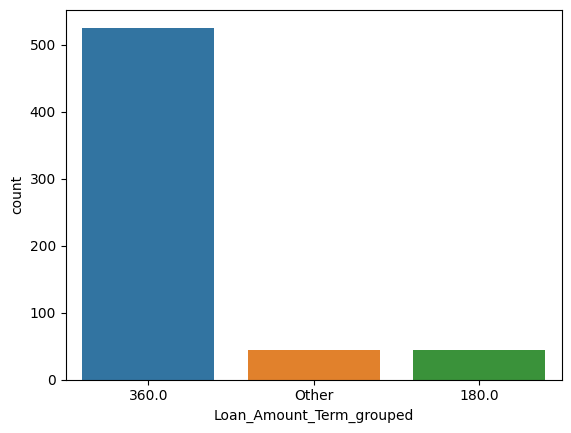

In [18]:
#New category visualized
sns.countplot(data=df, x="Loan_Amount_Term_grouped")

### Numeric values

From the histograms and boxplots above, we can see that the data is skewed to the right (aka positively skewed). The columns in question look at income and loan amounts. Based on the resource stated above (specifically this : Building a Credit Score Model: Handling Missing Values and Outliers https://medium.com/@zaynmuhammad20/building-a-credit-score-model-handling-missing-values-and-outliers-ceb501b3b7b7), it is stated that extreme incomes and loan amounts are valid values but only demonstrate few individuals. These values should not be removed but the data should be capped at 99%. Also extremely low values should be capped at 1%. This is called winsoration. For coapplicant income, the data will be capped at 99% but not at 1% because the data contains 0 also for people who don't have a coapplicant.

<br> This will not be done for the actual data, but a copy of it to avoid data leakage. This is done to demonstrate the need for winsoration. After winsoration, data will be transformed using log-transformation. This done to better identify outliers so they can be removed in the future steps of the analysis. To the copy of the data I will add column Has_Coapplicant to demonstrate if this has value.

<br> The findings from this will be used in the next notebook to deal with data.

In [19]:
df_trial = df.copy()
#Creating new column Has_Coapplicant in df
df_trial["Has_Coapplicant"] = ((df_trial["Coapplicant_Income"] > 0)).astype(object)

In [20]:
#Winsoration of Applicant_Income and Loan_Amount
for i in numeric_col:
    if i == "Coapplicant_Income":
        continue
    lower_limit = df_trial[i].quantile(0.01)
    upper_limit = df_trial[i].quantile(0.99)

    # Replace values directly in outlier_application_train
    df_trial[i] = np.clip(df_trial[i], lower_limit, upper_limit)

#Transforming Applicant_Income and Loan_Amount
df_trial["Applicant_Income_log"] = np.log1p(df_trial["Applicant_Income"])
df_trial["Loan_Amount_log"] = np.log1p(df_trial["Loan_Amount"])

#Cutting Coapplicant income at the 99%
upper = df_trial['Coapplicant_Income'].quantile(0.99) 
df_trial['CoapplicantIncome_capped'] = np.where(df_trial['Coapplicant_Income'] > upper, upper, 
                                                df_trial['Coapplicant_Income'])
#Log transforming Coapplicant_Incomes when Has_Coapplicant is 1
df_trial['CoapplicantIncome_log'] = df_trial['CoapplicantIncome_capped']
df_trial.loc[df_trial['Has_Coapplicant']==1,'CoapplicantIncome_log']=np.log1p(df_trial.loc[df_trial['Has_Coapplicant'] == 1, 
                                                                                           'CoapplicantIncome_capped'])

       Applicant_Income  Coapplicant_Income  Loan_Amount  \
count        614.000000          614.000000   614.000000   
mean        5214.577964         1621.245798   144.787687   
std         4528.770082         2926.248369    78.513474   
min         1025.000000            0.000000    30.650000   
25%         2877.500000            0.000000   100.250000   
50%         3812.500000         1188.500000   128.000000   
75%         5795.000000         2297.250000   164.750000   
max        32540.410000        41667.000000   495.870000   

       Applicant_Income_log  Loan_Amount_log  CoapplicantIncome_capped  \
count            614.000000       614.000000                614.000000   
mean               8.345881         4.867993               1483.654967   
std                0.599620         0.471099               1831.226927   
min                6.933423         3.454738                  0.000000   
25%                7.965024         4.617584                  0.000000   
50%            

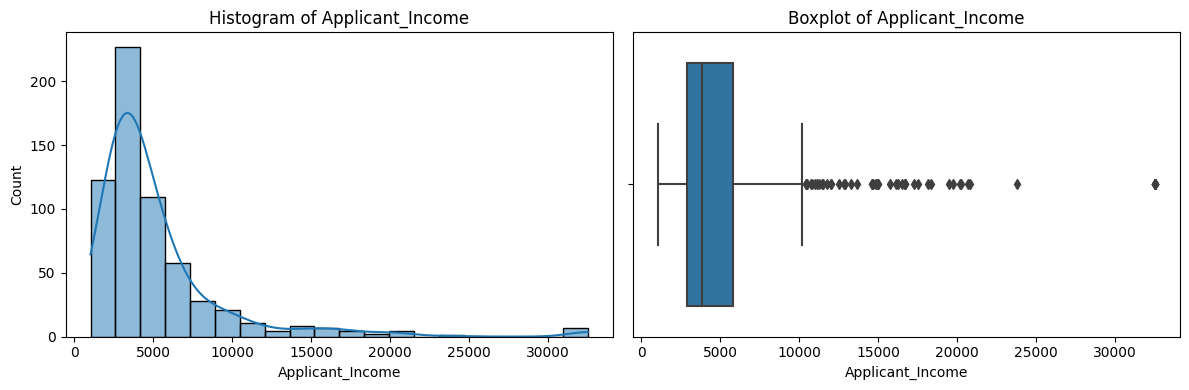

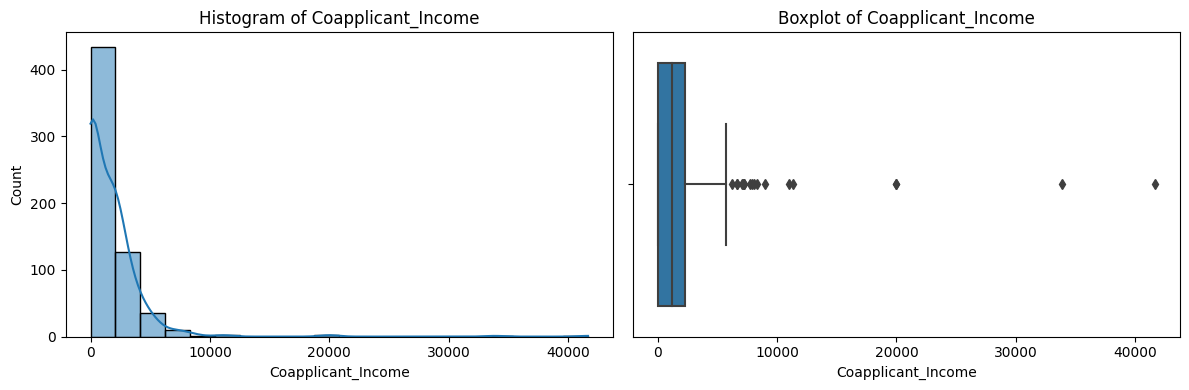

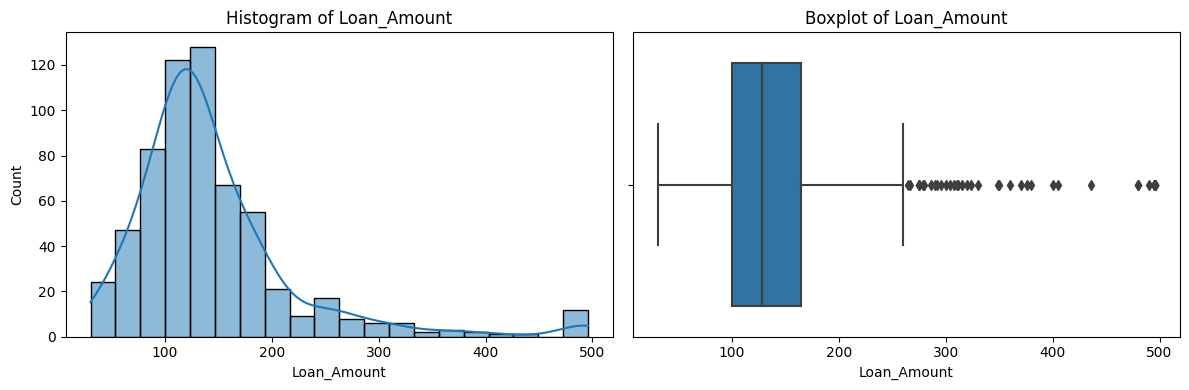

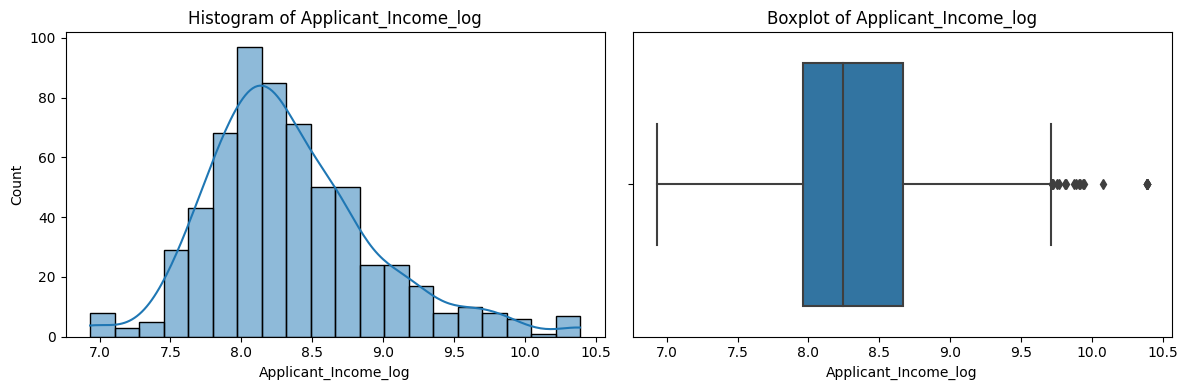

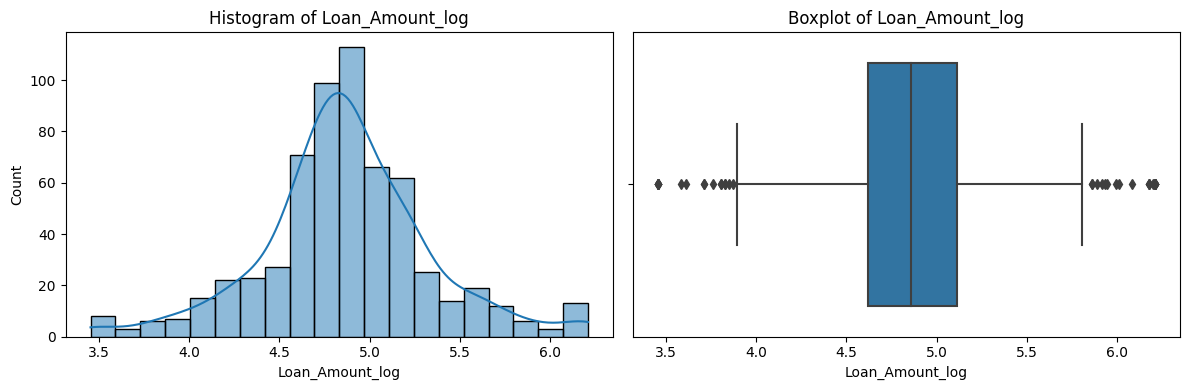

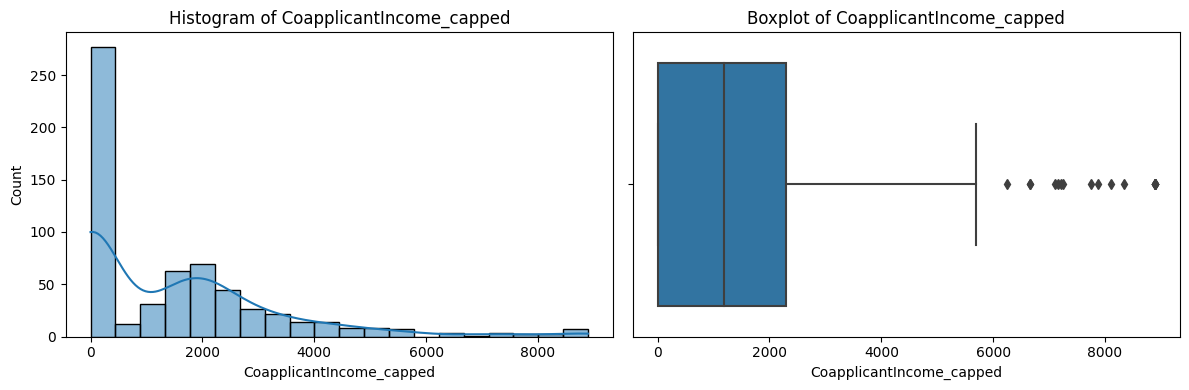

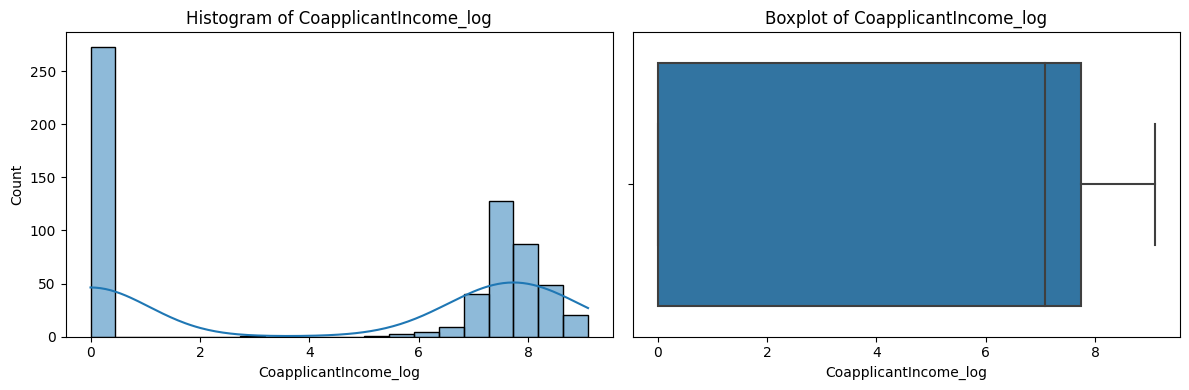

Skewness of numeric data:
 Applicant_Income            3.445069
Coapplicant_Income          7.491531
Loan_Amount                 2.235924
Applicant_Income_log        0.810885
Loan_Amount_log             0.059827
CoapplicantIncome_capped    1.611919
CoapplicantIncome_log      -0.180511
dtype: float64


In [21]:
numeric_cols = df_trial.select_dtypes(include=["float64"]).columns

print(df_trial.describe())
for i in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

    # Histogram
    sns.histplot(df_trial[i], bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {i}")

    # Boxplot
    sns.boxplot(x=df_trial[i], ax=axes[1])
    axes[1].set_title(f"Boxplot of {i}")

    plt.tight_layout()
    plt.show()
#Calculating skewness of data determine
for i in numeric_cols:
    skew = df_trial[numeric_cols].skew() 
print("Skewness of numeric data:\n", skew)

Data still appears as skewed, but significantly less than earlier. This can be expected because like mentioned before, people have a variety of incomes and loans but only a few have extrmely high ones. Two things need to be done to the data:
1. Data needs to be made more uniform before using it for designing a model. Applicant_Income_log and Loan_Amount_log both show clear outliers that need dealing with. 
2. The coapplicant income variable needs to be looked at from the prespective if the applicant has any dependents. It gets rid of the extreme positive skew and makes it slightly negative. This can be expected since there are values in the feature that contain 0. In the next notebook, it will evalueted if this is a redundant feature and if it could be replaced by Has_Coapplicant feature.

## Saving cleaned data for next steps

In [22]:
df.to_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets\loan_data_cleaned.csv", index=False)